In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import LeaveOneOut
import pandas as pd


import os

In [16]:
df_clip_base = pd.read_csv("confdf_results_csv/clip_base-clip.csv", index_col=0)
df_clip_large = pd.read_csv("confdf_results_csv/clip_large-clip_large.csv", index_col=0)

clip_results = {}
clip_large_results = {}

clip_threshold = 0.995
clip_large_threshold = 0.991

for video in df_clip_base["video_name"]:
    if df_clip_base[df_clip_base["video_name"] == video]["raw_pred_mean"].squeeze() < clip_threshold:
        clip_results[video] = 0
    else:
        clip_results[video] = 1

for video in df_clip_large["video_name"]:
    if df_clip_large[df_clip_large["video_name"] == video]["raw_pred_mean"].squeeze() < clip_large_threshold:
        clip_large_results[video] = 0
    else:
        clip_large_results[video] = 1

for video in clip_results.keys():
    if clip_results[video] != clip_large_results[video]:
        print(f"mismatch for {video} - base: {df_clip_base[df_clip_base["video_name"] == video]["raw_pred_mean"].squeeze()} - large: {df_clip_large[df_clip_large["video_name"] == video]["raw_pred_mean"].squeeze()}")

mismatch for 1eec2811670a1dfa0f697d099b0dfcdb_1920x1080_30 - base: 0.9712911 - large: 0.99879193
mismatch for 6cb2bf5384212402d39fc2653df913b7_1920x1080_30 - base: 0.9614033 - large: 0.9966918
mismatch for bruce_willis_1 - base: 0.9389125 - large: 0.9995159
mismatch for e9d9cee75745b4cc77e149448d8855d3_1080x1920_30 - base: 0.999229 - large: 0.95042706
mismatch for e47c246f3c2f0f66eca1a08aea644c57_1080x1920_30 - base: 0.9996847 - large: 0.97866666
mismatch for lucy_liu_3 - base: 0.98080003 - large: 0.9915848


In [49]:

df_results = pd.read_csv(f"confdf_results_csv/xception-xception_best.csv", index_col=0)
df_labels = df_results[["video_name", "label"]]


df_labels.to_csv("confdf_info_csv/videos_labels.csv", index=False)

In [2]:
selected_models = [
    'recce-recce_best',
    #'srm-srm_best',
    'xception-xception_best',
    #'clip_large-clip_large',
    'clip_base-clip',
    'spsl-spsl_best',
    'ucf-ucf_best',
    'effort-effort_ff_best'
    ]

df_video_by_detectors = pd.read_csv("confdf_info_csv/videos_labels.csv")


for file in os.listdir("confdf_results_csv"):
    if file.replace(".csv", "") in selected_models:

        df_results = pd.read_csv(f"confdf_results_csv/{file}", index_col=0)

        df_video_by_detectors[f"{file.split("-")[0]}_pred_mean"] = df_results["raw_pred_mean"]

#df_video_by_detectors = df_video_by_detectors.sort_values(["label", "video_name"])

display(df_video_by_detectors)

df_video_by_detectors.to_csv("confdf_info_csv/videos_by_detectors.csv", index=False)

,video_name,label,recce_pred_mean,effort_pred_mean,xception_pred_mean,clip_base_pred_mean,ucf_pred_mean,spsl_pred_mean
0,nile_red_2,1,0.999882,0.980044,0.999286,0.995934,0.999191,0.999323
1,dd5599c094537cb9fd32f33f43c06f87_1920x1080_30,0,0.013265,0.377038,0.029065,0.006391,0.008577,0.104179
2,talyor_swift_3,1,0.998343,0.977920,0.994439,0.999986,0.998743,0.985816
3,70e80388aae75b945e5000eb7ade4a6a_1920x1080_30,0,0.647860,0.455806,0.690315,0.674461,0.347482,0.870809
4,will_smith_2,1,0.999314,0.975835,0.999211,0.999940,0.999177,0.996915
...,...,...,...,...,...,...,...,...
79,bruce_willis_2,1,0.949844,0.963522,0.944011,0.999529,0.994007,0.996553
80,a4ea08e72606fb7ebd4347d79262823f_1920x1080_30,0,0.036198,0.803426,0.063876,0.128828,0.086554,0.129158
81,d02c5cdaee1215360fb80240d7a8901f_1080x1920_30,0,0.188374,0.389280,0.212857,0.823562,0.180960,0.425727
82,9bd3195d97edad5f200b325825dbb729_1920x1080_30,0,0.001499,0.361385,0.024312,0.987828,0.003133,0.230942


In [3]:

# X : Tableau (84, 6) -> Moyenne des prédictions des 6 détecteurs par vidéo
# y : Vecteur (84,) -> Vérité terrain (0 ou 1)
#X = df_video_by_detectors.drop(columns=["video_name", "label", "srm_pred_mean", "xception_pred_mean", "ucf_pred_mean", "clip_large_pred_mean", "spsl_pred_mean"])
X = df_video_by_detectors.drop(columns=["video_name", "label"])
y = df_video_by_detectors["label"]

# Utilisation de LogisticRegressionCV :
# 1. cv=LeaveOneOut() est parfait pour tes 84 points.
# 2. penalty='l2' empêche les poids de devenir trop extrêmes.
# 3. Cs=10 teste 10 forces de régularisation différentes pour trouver la meilleure.

model = LogisticRegressionCV(
    cv=LeaveOneOut(),
    penalty='l2',
    Cs=10, 
    random_state=49
)

model.fit(X, y)

# --- Analyse des résultats ---
print(f"Précision moyenne (LOOCV) : {model.scores_[1].mean():.2%}")
print("\nPoids des détecteurs :")
for i, weight in enumerate(model.coef_[0]):
    print(f"Détecteur {i+1} : {weight:.4f}")

print(f"Constante (Biais) : {model.intercept_[0]:.4f}")

print("LASSO")

model_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=100)
model_lasso.fit(X, y)

for i, weight in enumerate(model_lasso.coef_[0]):
    print(f"Détecteur {i+1} : {weight:.4f}")
print(f"Constante (Biais) : {model_lasso.intercept_[0]:.4f}")

# On valide avec un Stratified 5-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1342)
scores = cross_val_score(model_lasso, X, y, cv=cv)

print(f"Précision moyenne (5-Fold) : {scores.mean():.2%}")

Précision moyenne (LOOCV) : 76.90%

Poids des détecteurs :
Détecteur 1 : 0.4575
Détecteur 2 : 0.2363
Détecteur 3 : 0.4011
Détecteur 4 : 0.2756
Détecteur 5 : 0.4688
Détecteur 6 : 0.2556
Constante (Biais) : -1.3656
LASSO
Détecteur 1 : 11.5024
Détecteur 2 : 2.7000
Détecteur 3 : 0.0000
Détecteur 4 : 7.8335
Détecteur 5 : 1.1135
Détecteur 6 : -3.6984
Constante (Biais) : -14.0867
Précision moyenne (5-Fold) : 92.94%


In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import cross_val_predict, LeaveOneOut, StratifiedKFold
import matplotlib.pyplot as plt

# 1. Obtenir les probabilités et prédictions via LOOCV (Le plus rigoureux)
loo = LeaveOneOut()
y_probs_loo = cross_val_predict(model_lasso, X, y, cv=loo, method='predict_proba')[:, 1]
y_pred_loo = (y_probs_loo >= 0.5).astype(int)

# 2. Obtenir les probabilités et prédictions via 5-Fold (Lasso stable)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=1342)
y_probs_cv5 = cross_val_predict(model_lasso, X, y, cv=cv5, method='predict_proba')[:, 1]
y_pred_cv5 = (y_probs_cv5 >= 0.5).astype(int)

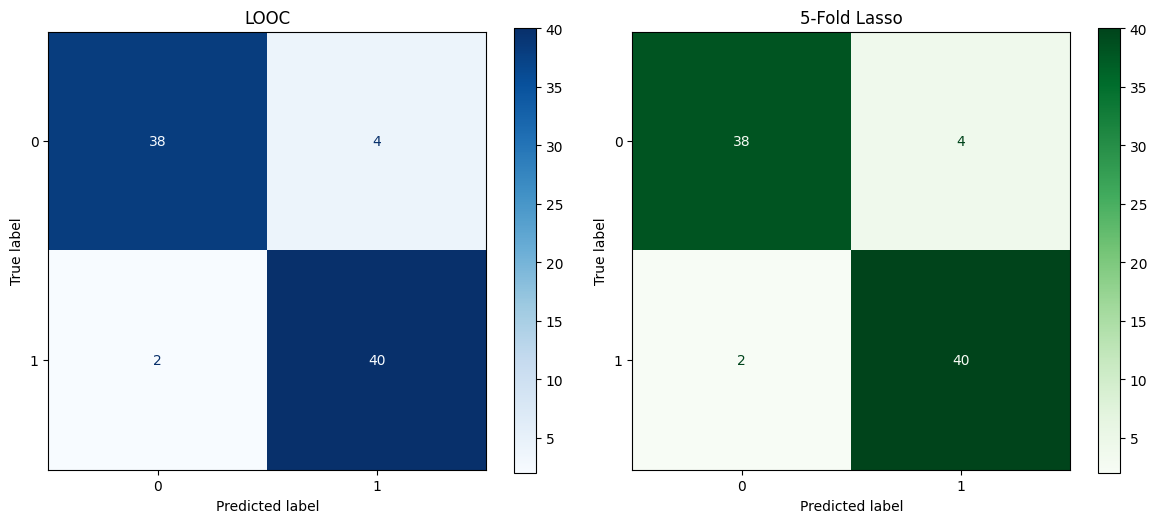

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Matrice LOOCV
ConfusionMatrixDisplay.from_predictions(y, y_pred_loo, ax=ax[0], cmap='Blues')
ax[0].set_title("LOOC")

# Matrice 5-Fold Lasso
ConfusionMatrixDisplay.from_predictions(y, y_pred_cv5, ax=ax[1], cmap='Greens')
ax[1].set_title("5-Fold Lasso")

plt.tight_layout()
plt.show()

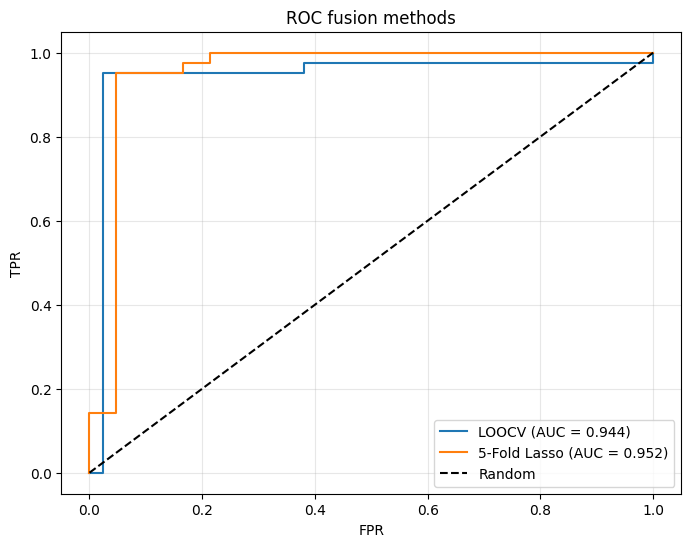

In [7]:
plt.figure(figsize=(8, 6))

# ROC pour LOOCV
fpr_loo, tpr_loo, _ = roc_curve(y, y_probs_loo)
roc_auc_loo = auc(fpr_loo, tpr_loo)
plt.plot(fpr_loo, tpr_loo, label=f'LOOCV (AUC = {roc_auc_loo:.3f})')

# ROC pour 5-Fold
fpr_cv5, tpr_cv5, _ = roc_curve(y, y_probs_cv5)
roc_auc_cv5 = auc(fpr_cv5, tpr_cv5)
plt.plot(fpr_cv5, tpr_cv5, label=f'5-Fold Lasso (AUC = {roc_auc_cv5:.3f})')

# Diagonale du hasard
plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC fusion methods')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [10]:
# 1. Obtenir les prédictions et les probabilités
y_pred = model_lasso.predict(X)
y_proba = model_lasso.predict_proba(X)[:, 1]

# 2. Identifier les erreurs
# Si y est une série Pandas, on utilise .values pour éviter les problèmes d'index
errors_idx = np.where(y_pred != np.array(y))[0]

print(f"--- Analyse des {len(errors_idx)} erreurs ---")
print(f"{'Vidéo ID':<10} | {'Vérité':<8} | {'Pred Lasso':<12} | {'Confiance':<10} | {'Score D1':<8}")
print("-" * 75)

for idx in errors_idx:
    verite = np.array(y)[idx]
    pred = y_pred[idx]
    
    # Calcul de la confiance (probabilité de la classe prédite)
    confiance = y_proba[idx] if pred == 1 else 1 - y_proba[idx]
    
    # Correction de l'accès à D1 : .iloc[ligne, colonne] pour Pandas
    # On force la conversion en numpy pour être tranquille
    if hasattr(X, 'iloc'):
        score_d1 = X.iloc[idx, 0]
    else:
        score_d1 = X[idx, 0]
    
    print(f"{idx:<10} | {verite:<8} | {pred:<12} | {confiance:.2%}   | {score_d1:.2%}")

--- Analyse des 2 erreurs ---
Vidéo ID   | Vérité   | Pred Lasso   | Confiance  | Score D1
---------------------------------------------------------------------------
9          | 0        | 1            | 96.44%   | 83.70%
42         | 1        | 0            | 67.52%   | 68.93%


In [11]:
from sklearn.model_selection import cross_val_score, LeaveOneOut, StratifiedKFold
import matplotlib.pyplot as plt

# On utilise ton modèle Lasso qui a bien fonctionné
model_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=100, random_state=42)

# 1. Calcul LOOCV (84 itérations)
loo = LeaveOneOut()
scores_loo = cross_val_score(model_lasso, X, y, cv=loo)

# 2. Calcul 5-Fold (5 itérations)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_skf = cross_val_score(model_lasso, X, y, cv=skf)

print(f"LOOCV : {scores_loo.mean():.2%} (Stabilité : +/- {scores_loo.std():.2%})")
print(f"5-Fold : {scores_skf.mean():.2%} (Stabilité : +/- {scores_skf.std():.2%})")

LOOCV : 92.86% (Stabilité : +/- 25.75%)
5-Fold : 92.79% (Stabilité : +/- 6.97%)


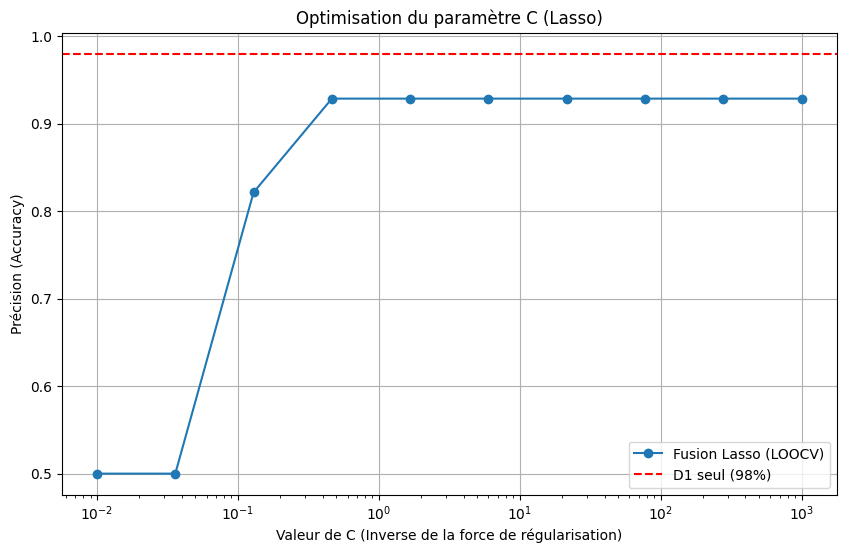

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import validation_curve, LeaveOneOut

# 1. Définir la plage de C à tester (échelle logarithmique)
param_range = np.logspace(-2, 3, 10) # De 0.01 à 1000

# 2. Calculer la courbe de validation avec LOOCV
train_scores, test_scores = validation_curve(
    LogisticRegression(penalty='l1', solver='liblinear', random_state=1342),
    X, y, param_name="C", param_range=param_range,
    cv=LeaveOneOut(), scoring="accuracy"
)

# 3. Calculer les moyennes
test_mean = np.mean(test_scores, axis=1)

# 4. Tracer le graphique
plt.figure(figsize=(10, 6))
plt.semilogx(param_range, test_mean, label="Fusion Lasso (LOOCV)", marker='o')

# Ajouter la ligne de référence pour D1 (98%)
plt.axhline(y=0.98, color='r', linestyle='--', label="D1 seul (98%)")

plt.title("Optimisation du paramètre C (Lasso)")
plt.xlabel("Valeur de C (Inverse de la force de régularisation)")
plt.ylabel("Précision (Accuracy)")
plt.legend(loc="best")
plt.grid(True)
plt.show()